### 1. Installing Dependencies

In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


### 2. Data Loading & Basic Data Inspection

In [4]:
df = pd.read_csv("src/data/processed_data/train.csv")
df.head()


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
df.shape

(1017209, 18)

In [6]:
df.dtypes

Store                          int64
DayOfWeek                      int64
Date                          object
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                  object
SchoolHoliday                  int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [8]:
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


### 3. Basic Data Preprocessing

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

In [10]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)


In [11]:
df = df[['Date','Store','Open','DayOfWeek','WeekOfYear','Month','Year','StoreType','Assortment','StateHoliday','SchoolHoliday','CompetitionDistance','CompetitionOpenSinceMonth','CompetitionOpenSinceYear','Promo','Promo2','Promo2SinceWeek','Promo2SinceYear','PromoInterval','Customers','Sales']]
df.head()

,Date,Store,Open,DayOfWeek,WeekOfYear,Month,Year,StoreType,Assortment,StateHoliday,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Customers,Sales
0,2015-07-31,1,1,5,31,7,2015,c,a,0,...,1270.0,9.0,2008.0,1,0,NaN,NaN,NaN,555,5263
1,2015-07-31,2,1,5,31,7,2015,a,a,0,...,570.0,11.0,2007.0,1,1,13.0,2010.0,"Jan,Apr,Jul,Oct",625,6064
2,2015-07-31,3,1,5,31,7,2015,a,a,0,...,14130.0,12.0,2006.0,1,1,14.0,2011.0,"Jan,Apr,Jul,Oct",821,8314
3,2015-07-31,4,1,5,31,7,2015,c,c,0,...,620.0,9.0,2009.0,1,0,NaN,NaN,NaN,1498,13995
4,2015-07-31,5,1,5,31,7,2015,a,a,0,...,29910.0,4.0,2015.0,1,0,NaN,NaN,NaN,559,4822


In [12]:
df['StateHoliday'].value_counts() #mixed int/str

StateHoliday
0    592943
0    393216
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [13]:
df["StateHoliday"] = df["StateHoliday"].astype(str).replace("0", "none")

In [14]:
df['StateHoliday'].value_counts()

StateHoliday
none    986159
a        20260
b         6690
c         4100
Name: count, dtype: int64

In [15]:
df['Store'].nunique()

1115

In [16]:
df['Date'].min().date(),df['Date'].max().date()

(datetime.date(2013, 1, 1), datetime.date(2015, 7, 31))

In [17]:
miss = df.isnull().sum()
miss

Date                              0
Store                             0
Open                              0
DayOfWeek                         0
WeekOfYear                        0
Month                             0
Year                              0
StoreType                         0
Assortment                        0
StateHoliday                      0
SchoolHoliday                     0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo                             0
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
Customers                         0
Sales                             0
dtype: int64

In [18]:
## missing percentage in each column
miss = miss[miss > 0]
for col, cnt in miss.items():
    print(f"  {col:<35} {cnt:>7,}  ({cnt/len(df)*100:.1f}%)")

  CompetitionDistance                   2,642  (0.3%)
  CompetitionOpenSinceMonth           323,348  (31.8%)
  CompetitionOpenSinceYear            323,348  (31.8%)
  Promo2SinceWeek                     508,031  (49.9%)
  Promo2SinceYear                     508,031  (49.9%)
  PromoInterval                       508,031  (49.9%)


In [19]:
df["Open"].value_counts() # 0 means Store closed

Open
1    844392
0    172817
Name: count, dtype: int64

In [20]:
zero_sales  = (df["Sales"] == 0).sum()
closed_rows = (df["Open"]  == 0).sum()
print(f"\n Zero-sales rows : {zero_sales:,}  ({zero_sales/len(df)*100:.1f}%)")
print(f"      Closed (Open=0) : {closed_rows:,} — will be DROPPED before modelling")
 


 Zero-sales rows : 172,871  (17.0%)
      Closed (Open=0) : 172,817 — will be DROPPED before modelling


In [21]:
df = df[(df["Open"] == 1) & (df["Sales"] > 0)]
len(df)

844338

### Univariate Analysis

#### 1. Sales

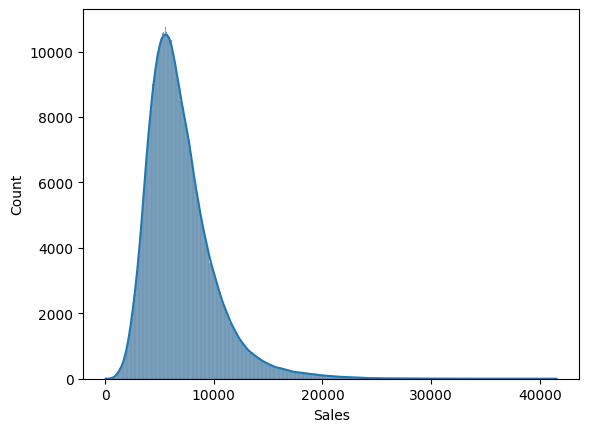

In [22]:
sns.histplot(data = df , x = "Sales", kde= True )
plt.show() # right skewed

In [23]:
s = df["Sales"]
print(f"\nSales distribution (open stores, sales>0)  n={len(df):,}")
print(f"  Mean    : {s.mean():>10,.1f}")
print(f"  Median  : {s.median():>10,.1f}")
print(f"  Std     : {s.std():>10,.1f}")
print(f"  Min/Max : {s.min():>10,.0f}  /  {s.max():>10,.0f}")
print(f"  Skew    : {s.skew():>10.3f}  >1 → right-skewed")
print(f"  Kurtosis: {s.kurtosis():>10.3f}")


Sales distribution (open stores, sales>0)  n=844,338
  Mean    :    6,956.0
  Median  :    6,369.0
  Std     :    3,103.8
  Min/Max :         46  /      41,551
  Skew    :      1.595  >1 → right-skewed
  Kurtosis:      4.854


#### 2. Customers

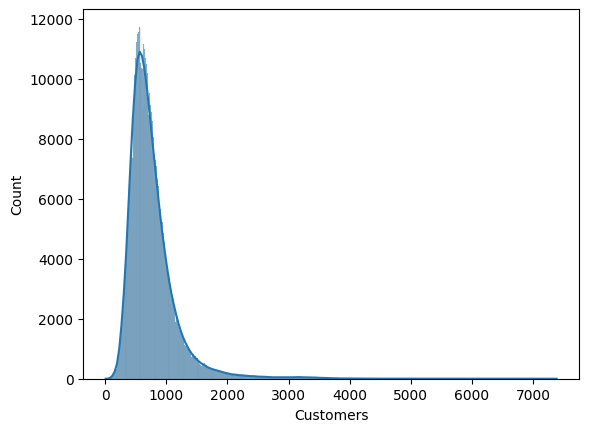

In [24]:
sns.histplot(data =df, x="Customers",kde = True)
plt.show()

#### 3. CompetitionDistance

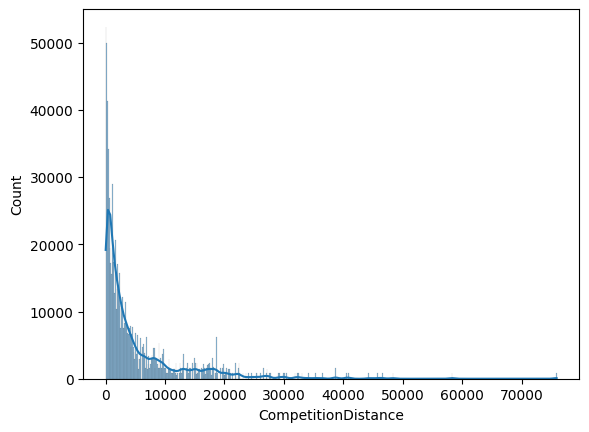

In [25]:
sns.histplot(data =df, x="CompetitionDistance",kde = True)
plt.show()

#### 4. StoreType

<Axes: xlabel='StoreType', ylabel='count'>

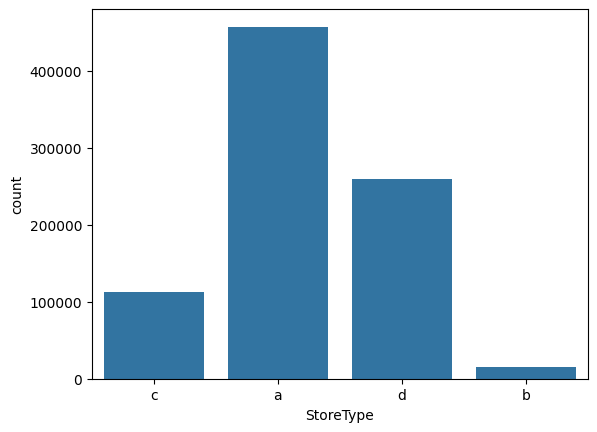

In [26]:
sns.countplot(data = df , x = "StoreType")

#### 5. SchoolHoliday

<Axes: xlabel='SchoolHoliday', ylabel='count'>

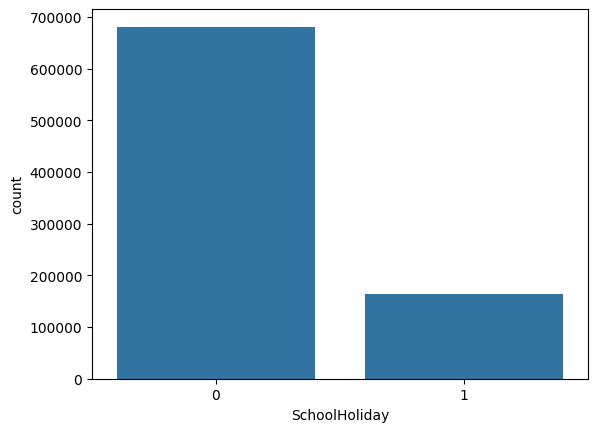

In [27]:
sns.countplot(data = df , x = "SchoolHoliday")

#### 6. StateHoliday

<Axes: xlabel='StateHoliday', ylabel='count'>

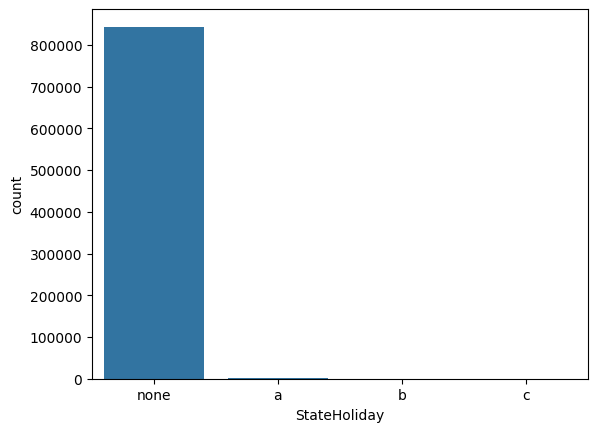

In [28]:
sns.countplot(data = df, x ="StateHoliday")

#### 7. Promo

<Axes: xlabel='Promo', ylabel='count'>

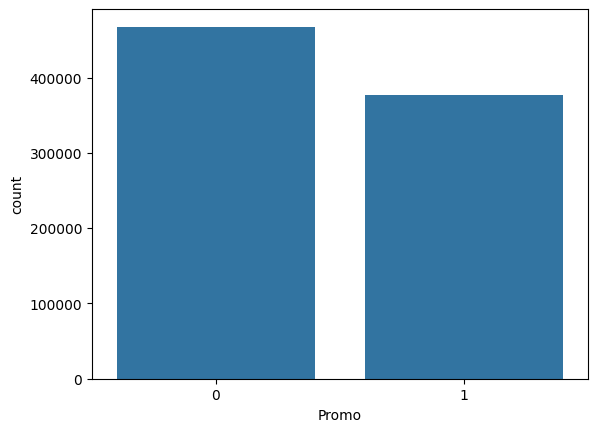

In [29]:
sns.countplot(data = df, x ="Promo")

### Bivariate Analysis

#### 1. Sales by StoreType 

In [30]:
r = df.groupby("StoreType")["Sales"].mean().round(0)


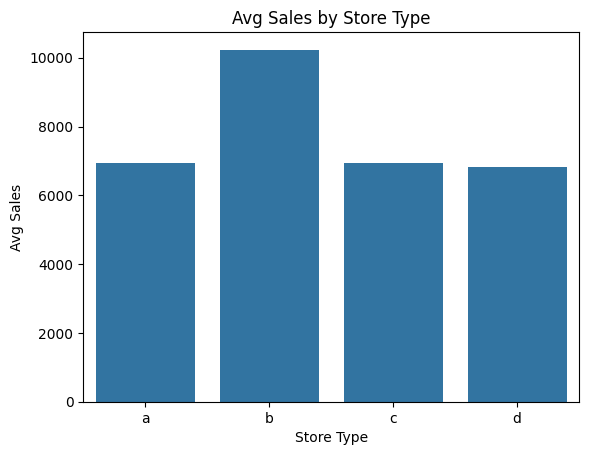

In [31]:
plot_df = r.reset_index()
plot_df.columns = ["StoreType", "TotalSales"]

sns.barplot( data=plot_df, x="StoreType", y="TotalSales")

plt.title("Avg Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Avg Sales")
plt.show()

#### 2. Sales by Assortment

In [32]:
r = df.groupby("Assortment")["Sales"].mean().round(0)
types = {"a" : "basic", "b" : "extra","c":"extended"}
avg_sales = []
for d, v in r.items():
    print(f"  {types[d]}: {v:,.0f}")
    avg_sales.append(v)


  basic: 6,622
  extra: 8,643
  extended: 7,301


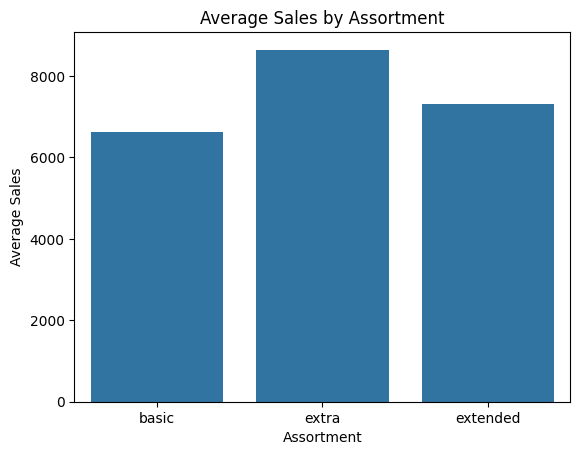

In [33]:
sns.barplot( x=["basic","extra","extended"], y=avg_sales)

plt.title("Average Sales by Assortment")
plt.xlabel("Assortment")
plt.ylabel("Average Sales")
plt.show()

#### 3. Sales by DayofWeek

In [34]:
dow = df.groupby("DayOfWeek")["Sales"].mean().round(0)
day_names = {1:"Mon",2:"Tue",3:"Wed",4:"Thu",5:"Fri",6:"Sat",7:"Sun"}
print(f"\n Mean sales by day of week:")
avg_sales = []
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
for d, v in dow.items():
    print(f"  {day_names[d]}: {v:,.0f}")
    avg_sales.append(v)


 Mean sales by day of week:
  Mon: 8,216
  Tue: 7,088
  Wed: 6,729
  Thu: 6,768
  Fri: 7,073
  Sat: 5,875
  Sun: 8,225


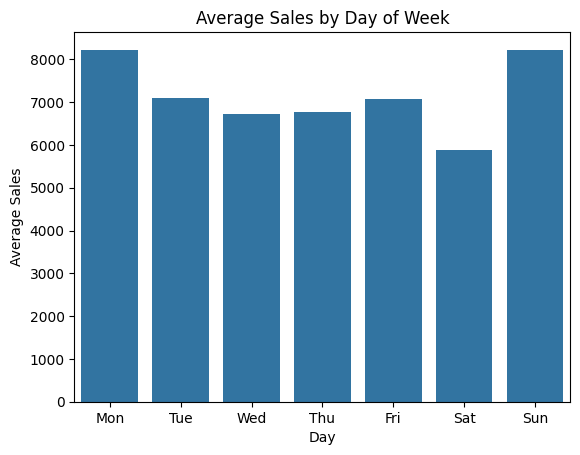

In [35]:
sns.barplot( x=days, y=avg_sales)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")
plt.show()

#### 4. Sales By Promo

<Axes: xlabel='Promo', ylabel='Sales'>

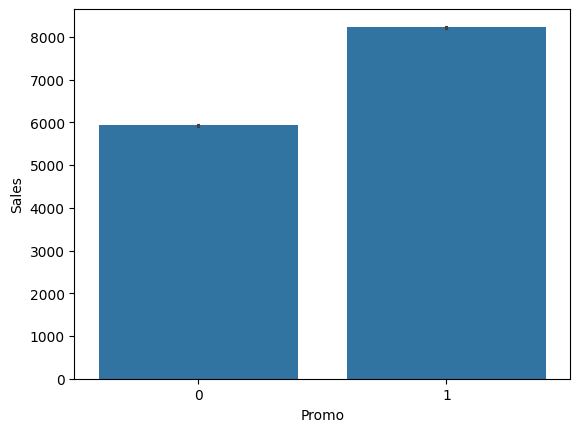

In [36]:
sns.barplot(data = df , x = "Promo",y ="Sales")

#### 5. Sales by Month

In [37]:
dow = df.groupby("Month")["Sales"].mean().round(0)
month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9 :"Sept",10 : "Oct",11 :"Nov",12 :"Dec"}
print(f"\n Mean sales by day of week:")

for m, v in dow.items():
    print(f"  {month_names[m]}: {v:,.0f}")


 Mean sales by day of week:
  Jan: 6,564
  Feb: 6,589
  Mar: 6,977
  Apr: 7,047
  May: 7,107
  Jun: 7,001
  Jul: 6,954
  Aug: 6,649
  Sept: 6,547
  Oct: 6,603
  Nov: 7,189
  Dec: 8,609


<Axes: xlabel='Month', ylabel='Sales'>

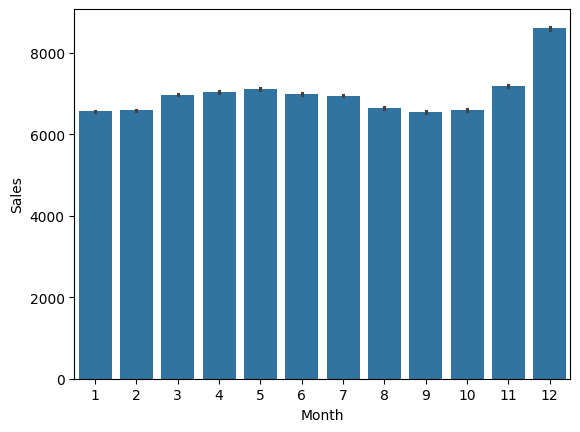

In [38]:
sns.barplot(data = df , x= "Month",y = "Sales")

#### 6. Sales vs Customers

<Axes: xlabel='Sales', ylabel='Customers'>

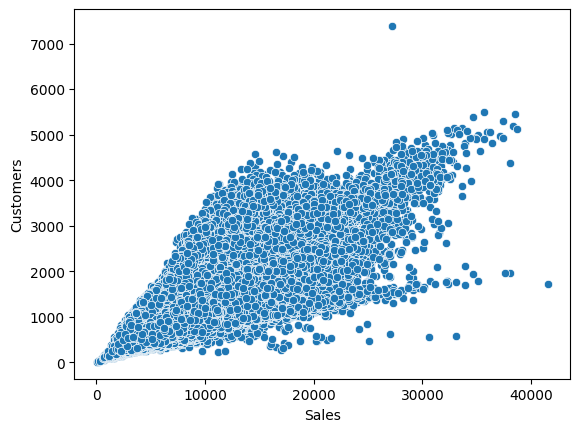

In [39]:
sns.scatterplot(data = df , x = "Sales", y = "Customers")

#### 7. Sales vs CompetitionDistance

<Axes: xlabel='Sales', ylabel='CompetitionDistance'>

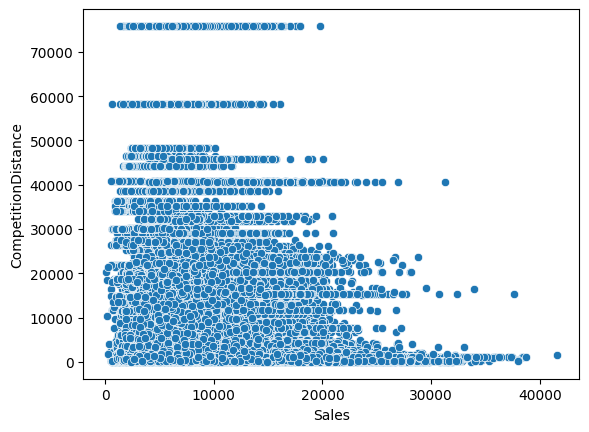

In [40]:
sns.scatterplot(data = df , x = "Sales", y = "CompetitionDistance")

In [41]:
r = df.groupby("SchoolHoliday")["Sales"].mean().round(0)
k = { 1 : "yes" , 0: "no" }
print(f"\n Mean sales by School Holiday:")

for m, v in r.items():
    print(f"  {k[m]}: {v:,.0f}")


 Mean sales by School Holiday:
  no: 6,897
  yes: 7,201


#### 8. Sales By SchoolHoliday

<Axes: xlabel='SchoolHoliday', ylabel='Sales'>

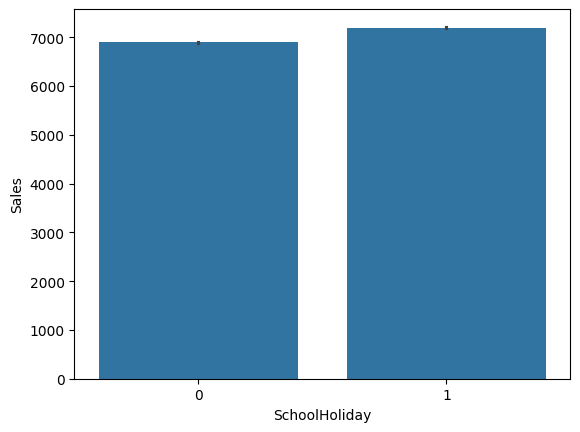

In [42]:
sns.barplot(data = df , x = "SchoolHoliday",y = "Sales")

### Multivariate Analysis

<Axes: >

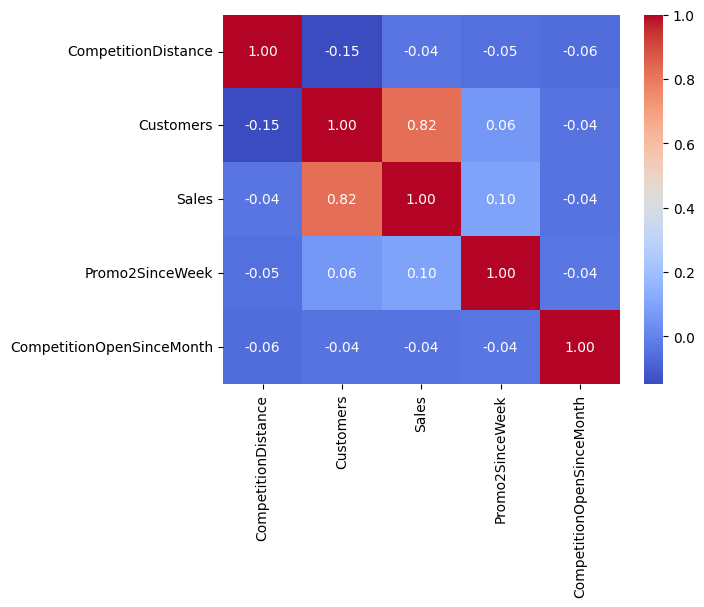

In [43]:
cols = ["CompetitionDistance","Customers","Sales","Promo2SinceWeek","CompetitionOpenSinceMonth"]
sns.heatmap(df[cols].corr(),annot=True,cmap="coolwarm",fmt=".2f")


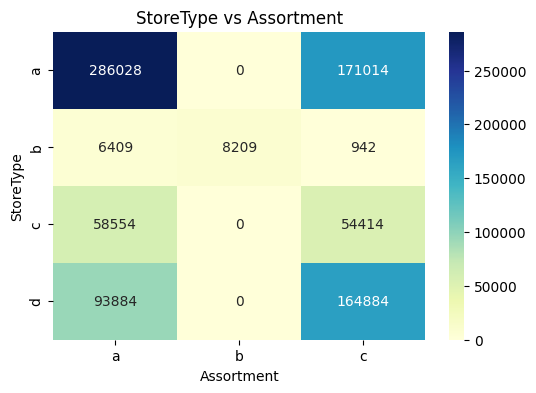

In [44]:
cross_tab = pd.crosstab(df["StoreType"],df["Assortment"])
plt.figure(figsize=(6, 4))
sns.heatmap(cross_tab,annot=True,fmt="d",cmap="YlGnBu")

plt.title("StoreType vs Assortment")
plt.xlabel("Assortment")
plt.ylabel("StoreType")
plt.show()

### Outlier Detection 

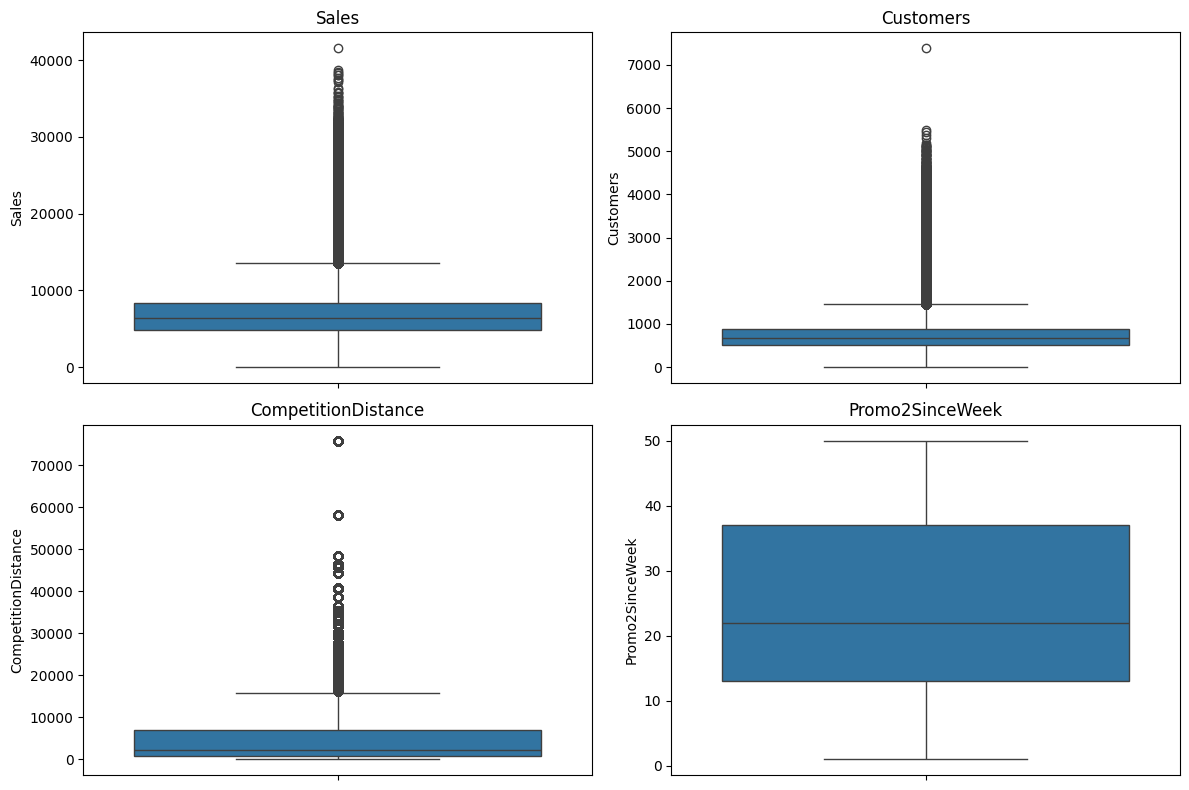

In [45]:
num_cols = ['Sales','Customers','CompetitionDistance','Promo2SinceWeek']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

### Preprocessing

In [46]:
df = df.drop(columns=['Open', 'Customers'])

In [47]:
## competition Distance
max_dist = df["CompetitionDistance"].max()  
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(max_dist )

`Missing Reason` : May be the store has no known nearby competitor at all.

`Approach` : Fill with a very large sentinel value (dataset maximum) - no competition nearby.

In [48]:
df["CompetitionDistance"].isnull().sum()

np.int64(0)

In [49]:
### competitionOpenSinceMonth & CompetitionOpenSinceyear
# Missing Reason - Either the competitor never existed, or opened so long ago the
# date was never recorded
# 
# Missing Stretegy :  Dont use raw month/year. Engineer one dervied feature - CompetitionOpenMonths
# (howmany months the competitor has been open). If missing fill with a large number rather than 0

df["CompetitionOpenMonths"] = (df["Date"].dt.year - df["CompetitionOpenSinceYear"]) * 12 + (df["Date"].dt.month - df["CompetitionOpenSinceMonth"])
df["CompetitionOpenMonths"] = df["CompetitionOpenMonths"].clip(lower=0)
df["CompetitionOpenMonths"] = df["CompetitionOpenMonths"].fillna(df["CompetitionOpenMonths"].max())

In [50]:
df = df.drop(columns=['CompetitionOpenSinceMonth','CompetitionOpenSinceYear'])

In [51]:
## promo2sinceYear & promo2sinceweek
##missing - promo2 = 0 for those stores - they never enrolled in promo2 at all.
## missing is structurally informative not random
## Approch : Engineer promo2activemonths (how long the store has been in promo2)
## if promo2 = 0 , fill with 0 

df["Promo2ActiveMonths"] = np.where(
    df["Promo2"] == 1, 
    (df["Date"].dt.year - df["Promo2SinceYear"]) * 12 +  (df["Date"].dt.isocalendar().week.astype(int) - df["Promo2SinceWeek"]) / 4.33 , 
    0
)

df["Promo2ActiveMonths"] = df["Promo2ActiveMonths"].clip(lower =0)

In [52]:
df = df.drop(columns=['Promo2SinceYear','Promo2SinceWeek'])

In [53]:
## promo interval :
# missing : promo2 = 0 stores no interval becuase they dont participate
# approch :  Engineer IsPromo2Active - a binary flag that checks whether the current
## observation month falls inside the store's promo interval

month_map = {
    "Jan":1, "Feb":2, "Mar":3, "Apr":4,  "May":5,  "Jun":6,
    "Jul":7, "Aug":8, "Sept":9, "Oct":10, "Nov":11, "Dec":12
}

def is_promo2_active(row):
    if row["Promo2"] == 0 or pd.isna(row["PromoInterval"]):
        return 0
    active_months = [month_map[m.strip()] for m in row["PromoInterval"].split(",")]
    return int(row["Date"].month in active_months)

df["IsPromo2Active"] = df.apply(is_promo2_active, axis=1)

In [54]:
df = df.drop(columns=['PromoInterval'])

In [55]:
df.isnull().sum().sum()

np.int64(0)

In [56]:
df.shape

(844338, 17)

### Feature Engineering

In [57]:
##log transforms
df["Sales"] = np.log1p(df["Sales"])

In [58]:
df['Sales'].skew()

np.float64(-0.1093269461587419)

<Axes: xlabel='Sales', ylabel='Count'>

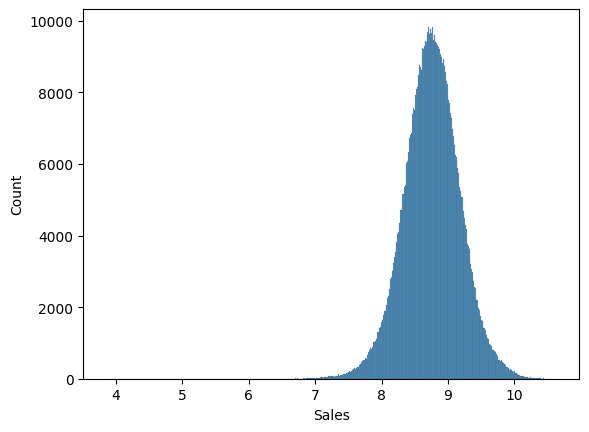

In [59]:
sns.histplot(data = df, x = "Sales")

In [60]:
df["CompetitionDistance"] = np.log1p(df["CompetitionDistance"])

<Axes: xlabel='CompetitionDistance', ylabel='Count'>

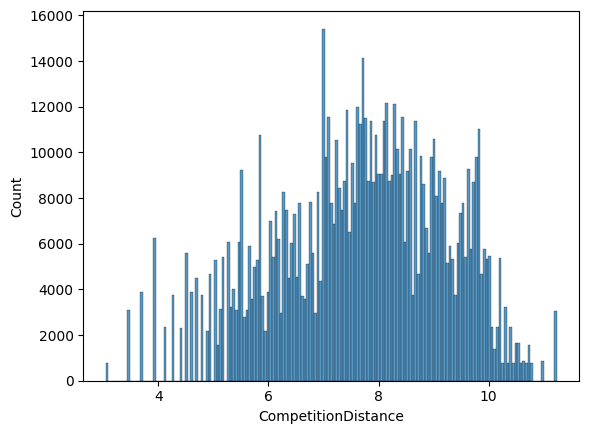

In [61]:
sns.histplot(df["CompetitionDistance"])

In [62]:
## categorical encoding
## Day of week - cylindrical encoding
df["DayOfWeek_sin"] = np.sin(2 * np.pi *df["DayOfWeek"] / 7)
df["DayOfWeek_cos"] = np.cos(2 * np.pi *df["DayOfWeek"] / 7)


In [63]:
df = df.drop(columns = ["DayOfWeek"])

In [64]:
storetype = pd.get_dummies(df["StoreType"], prefix="StoreType", dtype=int)
df = pd.concat([df, storetype], axis=1)
print(f"  StoreType     → one-hot: {list(storetype.columns)}")
df = df.drop(columns=["StoreType"])

  StoreType     → one-hot: ['StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d']


In [65]:
assortment_order = {"a": 0, "b": 1, "c": 2}
df["Assortment_ord"] = df["Assortment"].map(assortment_order)
print("  Assortment    → ordinal: basic=0, extra=1, extended=2")
df = df.drop(columns=["Assortment"])

  Assortment    → ordinal: basic=0, extra=1, extended=2


In [66]:
state_holiday = pd.get_dummies(df["StateHoliday"], prefix="Holiday", dtype=int)
df = pd.concat([df, state_holiday], axis=1)
print(f"  StateHoliday  → one-hot: {list(state_holiday.columns)}")
df = df.drop(columns=["StateHoliday"])


  StateHoliday  → one-hot: ['Holiday_a', 'Holiday_b', 'Holiday_c', 'Holiday_none']


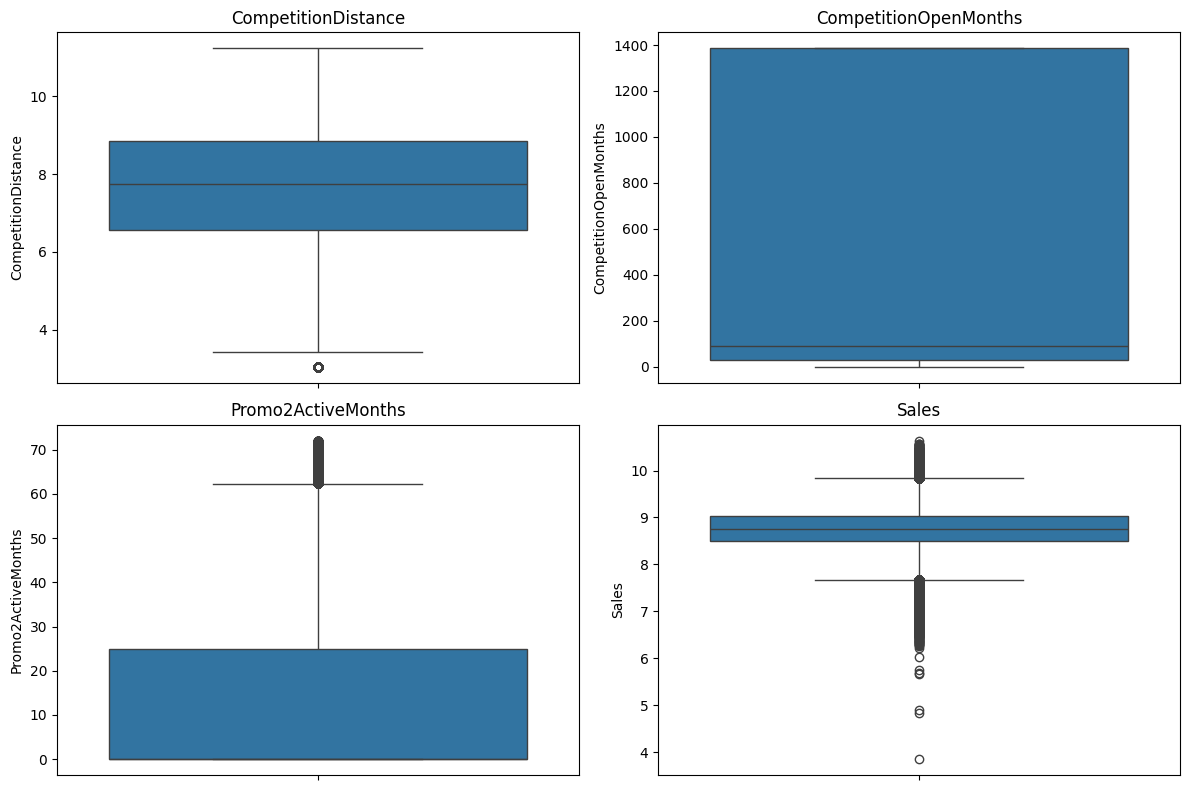

In [67]:
num_cols = ["CompetitionDistance","CompetitionOpenMonths","Promo2ActiveMonths","Sales"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


In [68]:
df.dtypes

Date                     datetime64[ns]
Store                             int64
WeekOfYear                        int64
Month                             int32
Year                              int32
SchoolHoliday                     int64
CompetitionDistance             float64
Promo                             int64
Promo2                            int64
Sales                           float64
CompetitionOpenMonths           float64
Promo2ActiveMonths              float64
IsPromo2Active                    int64
DayOfWeek_sin                   float64
DayOfWeek_cos                   float64
StoreType_a                       int64
StoreType_b                       int64
StoreType_c                       int64
StoreType_d                       int64
Assortment_ord                    int64
Holiday_a                         int64
Holiday_b                         int64
Holiday_c                         int64
Holiday_none                      int64
dtype: object

In [69]:
##log transforms
df["Promo2ActiveMonths"] = np.log1p(df["Promo2ActiveMonths"])

In [70]:
df.iloc[:, :10]

,Date,Store,WeekOfYear,Month,Year,SchoolHoliday,CompetitionDistance,Promo,Promo2,Sales
0,2015-07-31,1,31,7,2015,1,7.147559,1,0,8.568646
1,2015-07-31,2,31,7,2015,1,6.347389,1,1,8.710290
2,2015-07-31,3,31,7,2015,1,9.556126,1,1,9.025816
3,2015-07-31,4,31,7,2015,1,6.431331,1,0,9.546527
4,2015-07-31,5,31,7,2015,1,10.305982,1,0,8.481151
...,...,...,...,...,...,...,...,...,...,...
1016776,2013-01-01,682,1,1,2013,1,5.017280,0,0,8.124447
1016827,2013-01-01,733,1,1,2013,1,6.758095,0,0,9.284148
1016863,2013-01-01,769,1,1,2013,1,6.734592,0,1,8.524367
1017042,2013-01-01,948,1,1,2013,1,7.266129,0,0,8.410053


In [71]:
df = df.drop(columns=["Date"])

In [72]:
df.iloc[:, 10:]

,Promo2ActiveMonths,IsPromo2Active,DayOfWeek_sin,DayOfWeek_cos,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_ord,Holiday_a,Holiday_b,Holiday_c,Holiday_none
0,0.000000,0,-0.974928,-0.222521,0,0,1,0,0,0,0,0,1
1,4.176800,1,-0.974928,-0.222521,1,0,0,0,0,0,0,0,1
2,3.968897,1,-0.974928,-0.222521,1,0,0,0,0,0,0,0,1
3,0.000000,0,-0.974928,-0.222521,0,0,1,0,2,0,0,0,1
4,0.000000,0,-0.974928,-0.222521,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,0.000000,0,0.974928,-0.222521,0,1,0,0,0,1,0,0,0
1016827,0.000000,0,0.974928,-0.222521,0,1,0,0,1,1,0,0,0
1016863,0.763371,1,0.974928,-0.222521,0,1,0,0,1,1,0,0,0
1017042,0.000000,0,0.974928,-0.222521,0,1,0,0,1,1,0,0,0


In [73]:
num_cols = ["CompetitionDistance","CompetitionOpenMonths","Promo2ActiveMonths","Sales","Store","WeekOfYear","Month","Year"]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

In [74]:
y = df["Sales"]
X = df.drop(columns=["Sales"])

len(X)
X_test = X[800001 :]
X = X[:800001]
y_test = y[800001 : ]
y = y[:800001]


In [75]:
len(y_test)

44337

Helper functions ready ✓
Train : 800,001 rows
Test  : 44,337 rows

  XGBoost
  MAE   :       680.44
  RMSE  :       991.03
  R²    :       0.8792
  RMSPE :       0.2538  (lower = better)


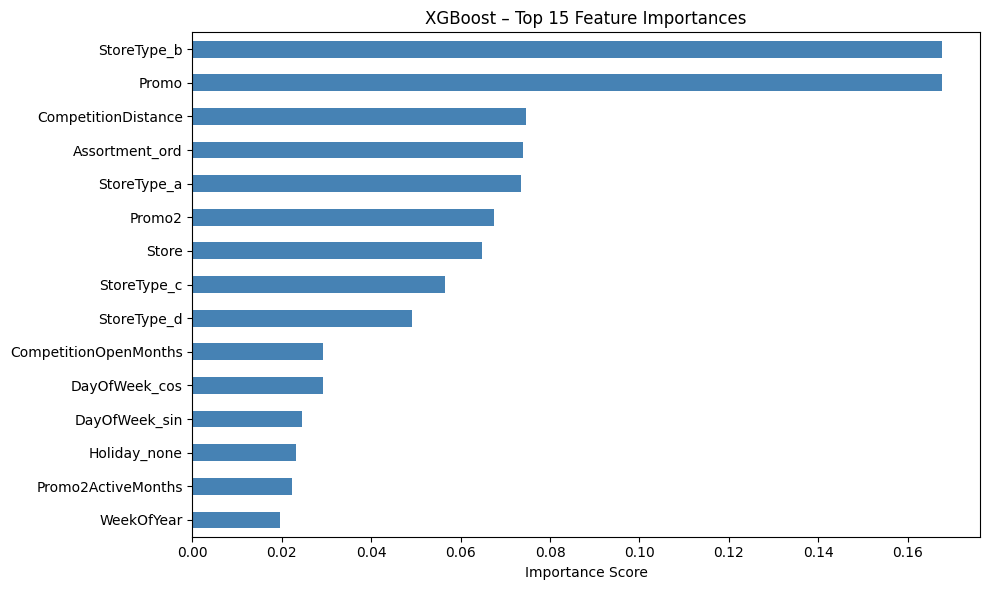

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024934 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1099
[LightGBM] [Info] Number of data points in the train set: 800001, number of used features: 22
[LightGBM] [Info] Start training from score 0.013572

  LightGBM
  MAE   :       682.81
  RMSE  :       983.75
  R²    :       0.8810
  RMSPE :       0.2546  (lower = better)

  Random Forest
  MAE   :       776.76
  RMSE  :     1,102.42
  R²    :       0.8505
  RMSPE :       0.2793  (lower = better)

── Model Comparison (Test Set) ──
        Model        MAE        RMSE       R2    RMSPE
      XGBoost 680.440355  991.033520 0.879220 0.253762
     LightGBM 682.806083  983.748004 0.880989 0.254605
Random Forest 776.763406 1102.420886 0.850544 0.279320


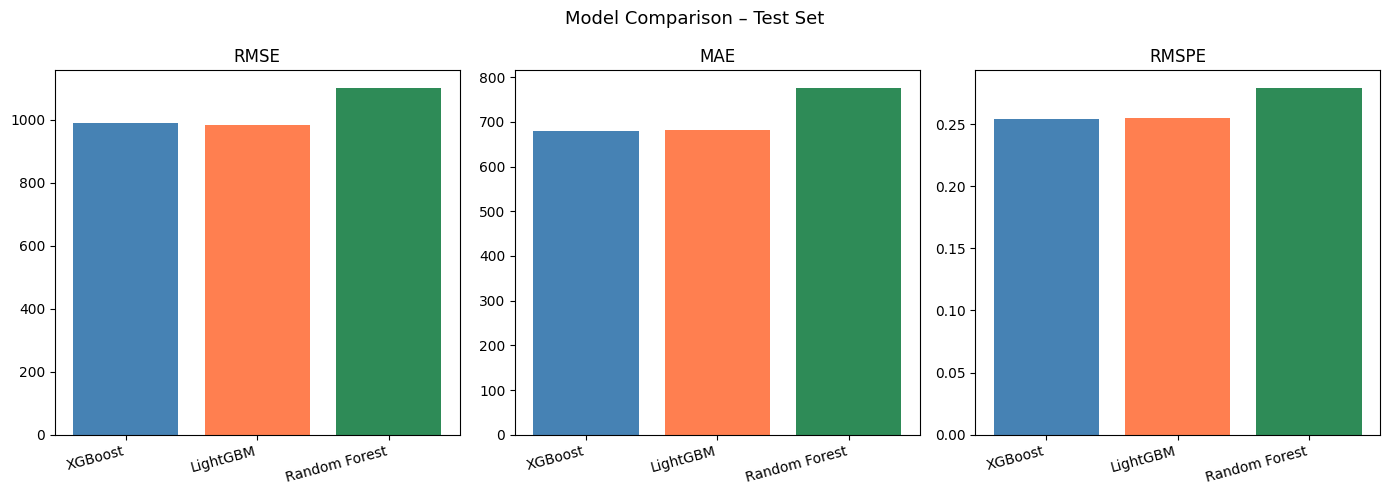

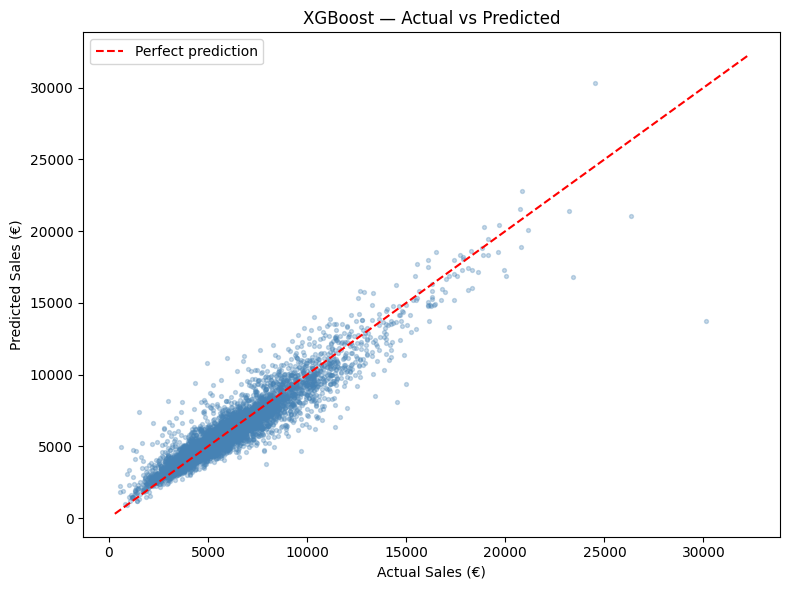


── XGBoost — Sample Predictions (first 10 rows) ──
 Actual_Sales_EUR  Predicted_Sales_EUR  Error_EUR  Error_Pct
           7656.0              7148.07    -507.93      -6.63
           7599.0              8322.12     723.12       9.52
           4753.0              4382.68    -370.32      -7.79
           2550.0              2968.37     418.37      16.41
           4105.0              5246.08    1141.08      27.80
           4147.0              3837.46    -309.54      -7.46
           3321.0              3858.44     537.44      16.18
           7165.0              6379.57    -785.43     -10.96
           9786.0              8268.38   -1517.62     -15.51
           2796.0              2923.62     127.62       4.56

All values are in real euros — no log or scaling artifacts ✓


In [77]:
"""
=============================================================
  ROSSMANN STORE SALES — MODEL TRAINING & PREDICTION CODE
=============================================================
  Paste each section as a new notebook cell.
  Assumes all preprocessing & feature engineering from
  k.ipynb has already been run.
  
  Split already done:
      X, y       → first 800 001 rows  (train)
      X_test, y_test → remaining rows  (test)
=============================================================
"""

# ─────────────────────────────────────────────────────────────
# CELL 1 – Imports & Inverse-Transform Helper
# ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def inverse_sales(scaled_log_sales, scaler, num_cols):
    """
    Undo StandardScaler → undo log1p → return real Sales (euros).
    """
    sales_idx = list(num_cols).index("Sales")
    mu  = scaler.mean_[sales_idx]
    std = scaler.scale_[sales_idx]
    log_sales  = np.array(scaled_log_sales) * std + mu   # undo scaler
    real_sales = np.expm1(log_sales)                     # undo log1p
    return real_sales

def rmspe(y_true, y_pred):
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

def eval_model(name, y_true_real, y_pred_real):
    mae       = mean_absolute_error(y_true_real, y_pred_real)
    rmse      = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
    r2        = r2_score(y_true_real, y_pred_real)
    rmspe_val = rmspe(y_true_real, y_pred_real)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  MAE   : {mae:>12,.2f}")
    print(f"  RMSE  : {rmse:>12,.2f}")
    print(f"  R²    : {r2:>12.4f}")
    print(f"  RMSPE : {rmspe_val:>12.4f}  (lower = better)")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "RMSPE": rmspe_val}

# num_cols — same list used when scaler.fit_transform() was called
num_cols = ["CompetitionDistance", "CompetitionOpenMonths", "Promo2ActiveMonths",
            "Sales", "Store", "WeekOfYear", "Month", "Year"]

# Convert test labels to real euros once; reused across all models
y_test_real = inverse_sales(y_test, scaler, num_cols)

print("Helper functions ready ✓")
print(f"Train : {X.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")


# ─────────────────────────────────────────────────────────────
# CELL 2 – MODEL 1 : XGBoost
# ─────────────────────────────────────────────────────────────
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators     = 1000,
    learning_rate    = 0.05,
    max_depth        = 8,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 1,
)

xgb_model.fit(X, y, verbose=100)

xgb_pred_test = inverse_sales(xgb_model.predict(X_test), scaler, num_cols)
xgb_metrics   = eval_model("XGBoost", y_test_real, xgb_pred_test)

# Feature Importance
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=False).head(15).plot(
    kind="barh", color="steelblue", figsize=(10, 6)
)
plt.gca().invert_yaxis()
plt.title("XGBoost – Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 3 – MODEL 2 : LightGBM
# ─────────────────────────────────────────────────────────────
from lightgbm import LGBMRegressor, log_evaluation

lgb_model = LGBMRegressor(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    num_leaves        = 127,
    max_depth         = -1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
)

lgb_model.fit(X, y, callbacks=[log_evaluation(100)])

lgb_pred_test = inverse_sales(lgb_model.predict(X_test), scaler, num_cols)
lgb_metrics   = eval_model("LightGBM", y_test_real, lgb_pred_test)


# ─────────────────────────────────────────────────────────────
# CELL 4 – MODEL 3 : Random Forest
# ─────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators     = 300,
    max_depth        = 20,
    min_samples_leaf = 10,
    max_features     = 0.6,
    random_state     = 42,
    n_jobs           = -1,
)

rf_model.fit(X, y)

rf_pred_test = inverse_sales(rf_model.predict(X_test), scaler, num_cols)
rf_metrics   = eval_model("Random Forest", y_test_real, rf_pred_test)


# ─────────────────────────────────────────────────────────────
# CELL 5 – Compare All Models
# ─────────────────────────────────────────────────────────────
results = pd.DataFrame([xgb_metrics, lgb_metrics, rf_metrics])
results = results.sort_values("RMSPE").reset_index(drop=True)

print("\n── Model Comparison (Test Set) ──")
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ["RMSE", "MAE", "RMSPE"]):
    ax.bar(results["Model"], results[metric], color=["steelblue", "coral", "seagreen"])
    ax.set_title(metric)
    ax.set_xticklabels(results["Model"], rotation=15, ha="right")
plt.suptitle("Model Comparison – Test Set", fontsize=13)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 6 – Actual vs Predicted  (best model)
# ─────────────────────────────────────────────────────────────
best_name = results.iloc[0]["Model"]
best_pred = {
    "XGBoost":       xgb_pred_test,
    "LightGBM":      lgb_pred_test,
    "Random Forest": rf_pred_test,
}[best_name]

sample = np.random.choice(len(y_test_real), size=min(5000, len(y_test_real)), replace=False)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_real[sample], best_pred[sample], alpha=0.3, s=8, color="steelblue")
mn, mx = y_test_real.min(), y_test_real.max()
plt.plot([mn, mx], [mn, mx], "r--", lw=1.5, label="Perfect prediction")
plt.xlabel("Actual Sales (€)")
plt.ylabel("Predicted Sales (€)")
plt.title(f"{best_name} — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 7 – Sample Prediction Output  (real euros)
# ─────────────────────────────────────────────────────────────
pred_df = pd.DataFrame({
    "Actual_Sales_EUR":    y_test_real,
    "Predicted_Sales_EUR": best_pred.round(2),
    "Error_EUR":           (best_pred - y_test_real).round(2),
    "Error_Pct":           (((best_pred - y_test_real) / y_test_real) * 100).round(2),
})

print(f"\n── {best_name} — Sample Predictions (first 10 rows) ──")
print(pred_df.head(10).to_string(index=False))
print("\nAll values are in real euros — no log or scaling artifacts ✓")

TensorFlow   : 2.21.0
GPU available: False
lstm_df shape : (844338, 9)
Columns       : ['Date', 'Store', 'Sales', 'DayOfWeek', 'Month', 'WeekOfYear', 'Promo', 'SchoolHoliday', 'StateHoliday_flag']
Stores        : 1115
Date range    : 2013-01-01  →  2015-07-31
Scaling done for 1115 stores ✓
Total sequences : 810,888
X shape : (810888, 30, 7)  → (samples, timesteps, features)
y shape : (810888,)
Train sequences : 762,234
Test  sequences : 48,654


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,153 (473.25 KB)

 Trainable params: 121,153 (473.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
670/670 ━━━━━━━━━━━━━━━━━━━━ 259s 382ms/step - loss: 0.0201 - mae: 0.1063 - val_loss: 0.0149 - val_mae: 0.0904 - learning_rate: 0.0010
Epoch 2/10
670/670 ━━━━━━━━━━━━━━━━━━━━ 294s 439ms/step - loss: 0.0134 - mae: 0.0868 - val_loss: 0.0120 - val_mae: 0.0821 - learning_rate: 0.0010
Epoch 3/10
670/670 ━━━━━━━━━━━━━━━━━━━━ 256s 381ms/step - loss: 0.0109 - mae: 0.0785 - val_loss: 0.0080 - val_mae: 0.0666 - learning_rate: 0.0010
Epoch 4/10
670/670 ━━━━━━━━━━━━━━━━━━━━ 265s 396ms/step - loss: 0.0080 - mae: 0.0671 - val_loss: 0.0064 - val_mae: 0.0588 - learning_rate: 0.0010
Epoch 5/10
670/670 ━━━━━━━━━━━━━━━━━━━━ 289s 431ms/step - loss: 0.0067 - mae: 0.0610 - val_loss: 0.0055 - val_mae: 0.0545 - learning_rate: 0.0010
Epoch 6/10
670/670 ━━━━━━━━━━━━━━━━━━━━ 2928s 4s/step - loss: 0.0060 - mae: 0.0576 - val_loss: 0.0050 - val_mae: 0.0523 - learning_rate: 0.0010
Epoch 7/10
670/670 ━━━━━━━━━━━━━━━━━━━━ 480s 716ms/step - loss: 0.0056 - mae: 0.0555 - val_loss: 0.0047 - val_mae: 0.0506 - le

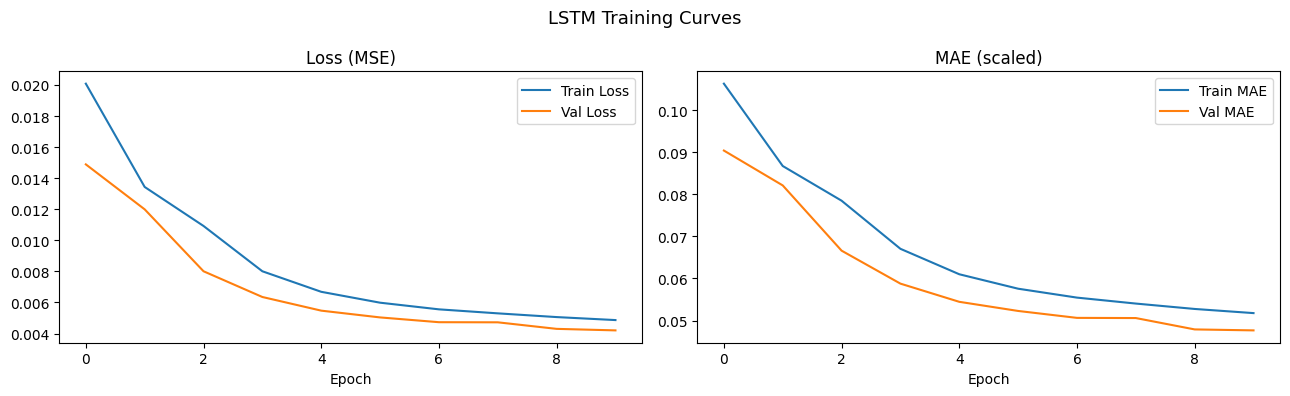

Inverse transform done ✓
Sample predictions : [3575.01 3103.92 5176.39 4787.47 4807.84]
Sample actuals     : [2983. 2868. 5101. 5218. 5140.]

  LSTM — Test Set Results
  MAE   :       558.39
  RMSE  :       811.40
  R²    :       0.9353
  RMSPE :       0.2846  (lower = better)


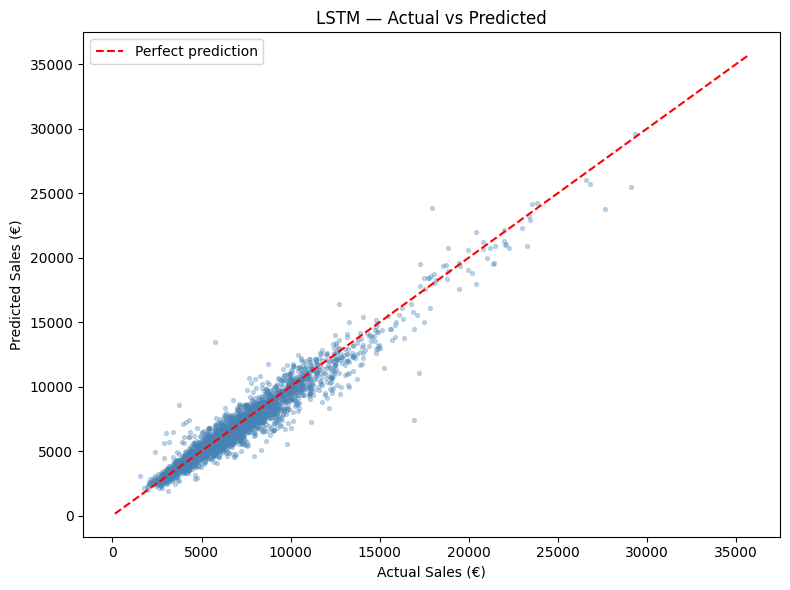


── Sample Predictions (first 10 rows) ──
 Actual_Sales_EUR  Predicted_Sales_EUR  Error_EUR  Error_Pct
           2983.0              3575.01     592.01      19.85
           2868.0              3103.92     235.92       8.23
           5101.0              5176.39      75.39       1.48
           5218.0              4787.47    -430.53      -8.25
           5140.0              4807.84    -332.16      -6.46
           4353.0              4954.15     601.15      13.81
           4097.0              3925.51    -171.49      -4.19
           3090.0              3080.38      -9.62      -0.31
           4359.0              4176.03    -182.97      -4.20
           3871.0              3420.50    -450.50     -11.64

All values are in real euros ✓


In [80]:
"""
=============================================================
  ROSSMANN STORE SALES — LSTM MODEL
=============================================================
  Run this from the TOP of your notebook, right after:
      df = df[(df["Open"] == 1) & (df["Sales"] > 0)]
      df["Date"] = pd.to_datetime(df["Date"])
      df["Month"] / df["Year"] / df["WeekOfYear"] already added

  The XGBoost pipeline dropped Date, DayOfWeek, StateHoliday.
  This LSTM pipeline branches off BEFORE those drops.
  Use the original df (before any feature engineering).
=============================================================
"""

# ─────────────────────────────────────────────────────────────
# CELL 1 – Imports
# ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"TensorFlow   : {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")


# ─────────────────────────────────────────────────────────────
# CELL 2 – Rebuild LSTM dataframe from scratch
#          (uses original df — open stores, sales > 0 only)
# ─────────────────────────────────────────────────────────────
# Re-load so we are completely independent of the XGBoost pipeline
lstm_df = pd.read_csv("src/data/processed_data/train.csv")
lstm_df["Date"] = pd.to_datetime(lstm_df["Date"])

# Same filters as your notebook
lstm_df = lstm_df[(lstm_df["Open"] == 1) & (lstm_df["Sales"] > 0)].copy()

# Add time features (same as your notebook)
lstm_df["Month"]     = lstm_df["Date"].dt.month
lstm_df["WeekOfYear"] = lstm_df["Date"].dt.isocalendar().week.astype(int)
# DayOfWeek already present in the raw CSV

# Fix StateHoliday mixed type (same as your notebook)
lstm_df["StateHoliday"] = lstm_df["StateHoliday"].astype(str).replace("0", "none")

# ── Collapse StateHoliday → binary flag ──
lstm_df["StateHoliday_flag"] = (lstm_df["StateHoliday"] != "none").astype(int)

# ── Keep only the 8 columns the LSTM needs ──
lstm_df = lstm_df[[
    "Date", "Store", "Sales",
    "DayOfWeek", "Month", "WeekOfYear",
    "Promo", "SchoolHoliday", "StateHoliday_flag"
]].copy()

# Log-transform Sales
lstm_df["Sales"] = np.log1p(lstm_df["Sales"])

# Sort chronologically within each store
lstm_df = lstm_df.sort_values(["Store", "Date"]).reset_index(drop=True)

print(f"lstm_df shape : {lstm_df.shape}")
print(f"Columns       : {list(lstm_df.columns)}")
print(f"Stores        : {lstm_df['Store'].nunique()}")
print(f"Date range    : {lstm_df['Date'].min().date()}  →  {lstm_df['Date'].max().date()}")


# ─────────────────────────────────────────────────────────────
# CELL 3 – Per-Store MinMaxScaling
# ─────────────────────────────────────────────────────────────
SCALE_COLS = ["Sales", "DayOfWeek", "Month", "WeekOfYear"]
# Promo / SchoolHoliday / StateHoliday_flag are already 0/1 — no scaling needed

store_scalers = {}
scaled_parts  = []

for store_id, grp in lstm_df.groupby("Store"):
    sc  = MinMaxScaler()
    grp = grp.copy()
    grp[SCALE_COLS] = sc.fit_transform(grp[SCALE_COLS])
    store_scalers[store_id] = sc
    scaled_parts.append(grp)

lstm_scaled = pd.concat(scaled_parts).sort_values(["Store", "Date"]).reset_index(drop=True)

print(f"Scaling done for {len(store_scalers)} stores ✓")


# ─────────────────────────────────────────────────────────────
# CELL 4 – Sequence Builder
# ─────────────────────────────────────────────────────────────
SEQ_LEN = 30   # use 30 days of history to predict day 31

INPUT_COLS = ["Sales", "Promo", "SchoolHoliday",
              "StateHoliday_flag", "DayOfWeek", "Month", "WeekOfYear"]
TARGET_COL = "Sales"

def build_sequences(df_store, seq_len, input_cols, target_col):
    data = df_store[input_cols].values.astype(np.float32)
    tgt  = df_store[target_col].values.astype(np.float32)
    Xs, ys = [], []
    for i in range(len(data) - seq_len):
        Xs.append(data[i : i + seq_len])
        ys.append(tgt[i + seq_len])
    return np.array(Xs), np.array(ys)

all_X, all_y, all_store = [], [], []

for store_id, grp in lstm_scaled.groupby("Store"):
    grp = grp.sort_values("Date")
    X_s, y_s = build_sequences(grp, SEQ_LEN, INPUT_COLS, TARGET_COL)
    all_X.append(X_s)
    all_y.append(y_s)
    all_store.extend([store_id] * len(y_s))

all_X     = np.concatenate(all_X, axis=0)
all_y     = np.concatenate(all_y, axis=0)
all_store = np.array(all_store)

print(f"Total sequences : {len(all_X):,}")
print(f"X shape : {all_X.shape}  → (samples, timesteps, features)")
print(f"y shape : {all_y.shape}")


# ─────────────────────────────────────────────────────────────
# CELL 5 – Train / Test Split  (chronological ~94% / 6%)
# ─────────────────────────────────────────────────────────────
SPLIT = int(len(all_X) * 0.94)

X_train, X_test  = all_X[:SPLIT],  all_X[SPLIT:]
y_train, y_test  = all_y[:SPLIT],  all_y[SPLIT:]
store_test        = all_store[SPLIT:]

print(f"Train sequences : {len(X_train):,}")
print(f"Test  sequences : {len(X_test):,}")


# ─────────────────────────────────────────────────────────────
# CELL 6 – Build LSTM Model
# ─────────────────────────────────────────────────────────────
N_FEATURES = X_train.shape[2]

model = Sequential([
    Input(shape=(SEQ_LEN, N_FEATURES)),

    LSTM(128, return_sequences=True),
    Dropout(0.2),

    LSTM(64, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation="relu"),
    Dense(1),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)

model.summary()


# ─────────────────────────────────────────────────────────────
# CELL 7 – Train
# ─────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train,
    epochs           = 10,
    batch_size       = 1024,
    validation_split = 0.1,
    callbacks        = callbacks,
    verbose          = 1,
)


# ─────────────────────────────────────────────────────────────
# CELL 8 – Training Curves
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["loss"],     label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["mae"],     label="Train MAE")
axes[1].plot(history.history["val_mae"], label="Val MAE")
axes[1].set_title("MAE (scaled)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.suptitle("LSTM Training Curves", fontsize=13)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 9 – Inverse Transform → Real Sales (euros)
# ─────────────────────────────────────────────────────────────
def inverse_to_real_sales(scaled_values, store_id, store_scalers, scale_cols):
    """
    Undo MinMaxScaler on Sales column → undo log1p → real euros.
    """
    sc        = store_scalers[store_id]
    sales_idx = scale_cols.index("Sales")
    n         = len(np.atleast_1d(scaled_values))

    dummy = np.zeros((n, len(scale_cols)))
    dummy[:, sales_idx] = np.atleast_1d(scaled_values)

    log_sales = sc.inverse_transform(dummy)[:, sales_idx]
    return np.expm1(log_sales)


y_pred_scaled = model.predict(X_test, batch_size=2048, verbose=0).flatten()

y_pred_real = np.array([
    inverse_to_real_sales(np.array([p]), sid, store_scalers, SCALE_COLS)[0]
    for p, sid in zip(y_pred_scaled, store_test)
])

y_test_real = np.array([
    inverse_to_real_sales(np.array([t]), sid, store_scalers, SCALE_COLS)[0]
    for t, sid in zip(y_test, store_test)
])

print("Inverse transform done ✓")
print(f"Sample predictions : {y_pred_real[:5].round(2)}")
print(f"Sample actuals     : {y_test_real[:5].round(2)}")


# ─────────────────────────────────────────────────────────────
# CELL 10 – Evaluation
# ─────────────────────────────────────────────────────────────
def rmspe(y_true, y_pred):
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

mae       = mean_absolute_error(y_test_real, y_pred_real)
rmse      = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2        = r2_score(y_test_real, y_pred_real)
rmspe_val = rmspe(y_test_real, y_pred_real)

print(f"\n{'='*50}")
print(f"  LSTM — Test Set Results")
print(f"{'='*50}")
print(f"  MAE   : {mae:>12,.2f}")
print(f"  RMSE  : {rmse:>12,.2f}")
print(f"  R²    : {r2:>12.4f}")
print(f"  RMSPE : {rmspe_val:>12.4f}  (lower = better)")


# ─────────────────────────────────────────────────────────────
# CELL 11 – Actual vs Predicted
# ─────────────────────────────────────────────────────────────
sample = np.random.choice(len(y_test_real), size=min(3000, len(y_test_real)), replace=False)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_real[sample], y_pred_real[sample],
            alpha=0.3, s=8, color="steelblue")
mn, mx = y_test_real.min(), y_test_real.max()
plt.plot([mn, mx], [mn, mx], "r--", lw=1.5, label="Perfect prediction")
plt.xlabel("Actual Sales (€)")
plt.ylabel("Predicted Sales (€)")
plt.title("LSTM — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 12 – Prediction Output Table
# ─────────────────────────────────────────────────────────────
pred_df = pd.DataFrame({
    "Actual_Sales_EUR":    y_test_real.round(2),
    "Predicted_Sales_EUR": y_pred_real.round(2),
    "Error_EUR":           (y_pred_real - y_test_real).round(2),
    "Error_Pct":           (((y_pred_real - y_test_real) / y_test_real) * 100).round(2),
})

print("\n── Sample Predictions (first 10 rows) ──")
print(pred_df.head(10).to_string(index=False))
print("\nAll values are in real euros ✓")